In [3]:
import numpy as np
from matplotlib import pyplot as plt
import torch

In [4]:
# Data load
data=np.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/data/2026_03_18_CFRP_FBH_3s_30s_top_symetrical.npz",allow_pickle=True)

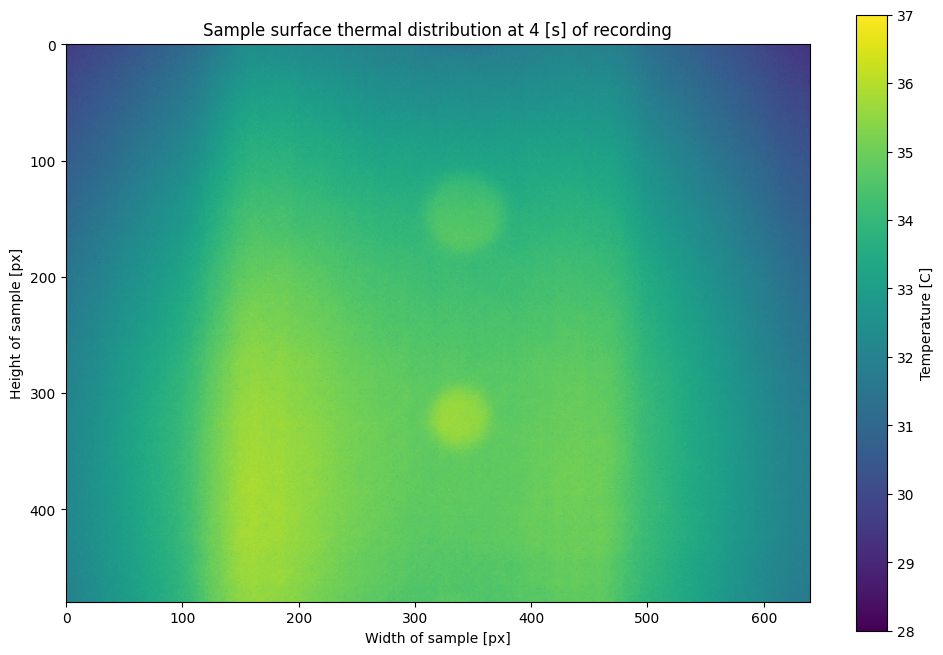

In [5]:
# Plotting the camera recording at given frame
plt.figure(figsize=(12,8))
plt.imshow(data['data'][200,:,:]/100-273.5,vmin=28,vmax=37)
plt.xlabel('Width of sample [px]')
plt.ylabel('Height of sample [px]')
plt.title('Sample surface thermal distribution at 4 [s] of recording')
plt.colorbar(label='Temperature [C]')

In [6]:
from scipy.signal import savgol_filter

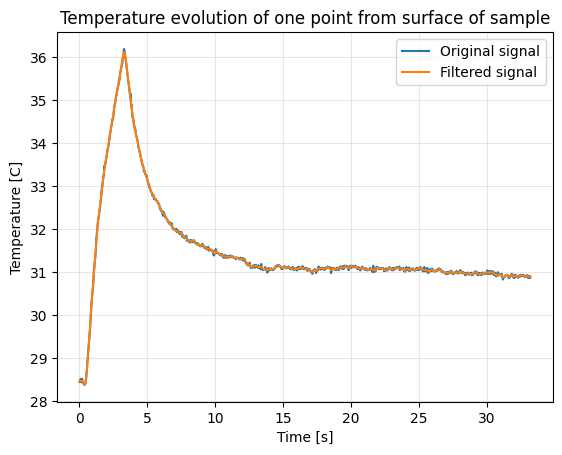

In [7]:
T,H,W=data['data'].shape
H_center=H//2
W_center=W//2

x_t=data['data'][:,H_center,W_center]/100-273.5 # Conversion to the [C]
t=np.linspace(0,T/50,T)

x_t_sav = savgol_filter(x_t, window_length=19, polyorder=3, axis=0)

plt.plot(t,x_t,label='Original signal')
plt.plot(t,x_t_sav,label='Filtered signal')

plt.grid(alpha=0.3)
plt.xlabel('Time [s]')
plt.ylabel('Temperature [C]')
plt.title('Temperature evolution of one point from surface of sample')
plt.legend()

In [8]:
d_loss=torch.load('/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_5000_epoch/data_loss.pt')
p_loss=torch.load('/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_5000_epoch/pde_loss.pt')
t_loss=torch.load('/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_5000_epoch/total_loss_1.pt')

In [9]:
d_loss_2=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch/data_loss.pt")
p_loss_2=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch/pde_loss.pt")
t_loss_2=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch/total_loss_1.pt")

In [10]:
a_x_track=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch/a_x_track.pt")
a_y_track=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch/a_y_track.pt")
a_z_track=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch/a_z_track.pt")

Text(0.5, 1.0, 'Training of PINN')

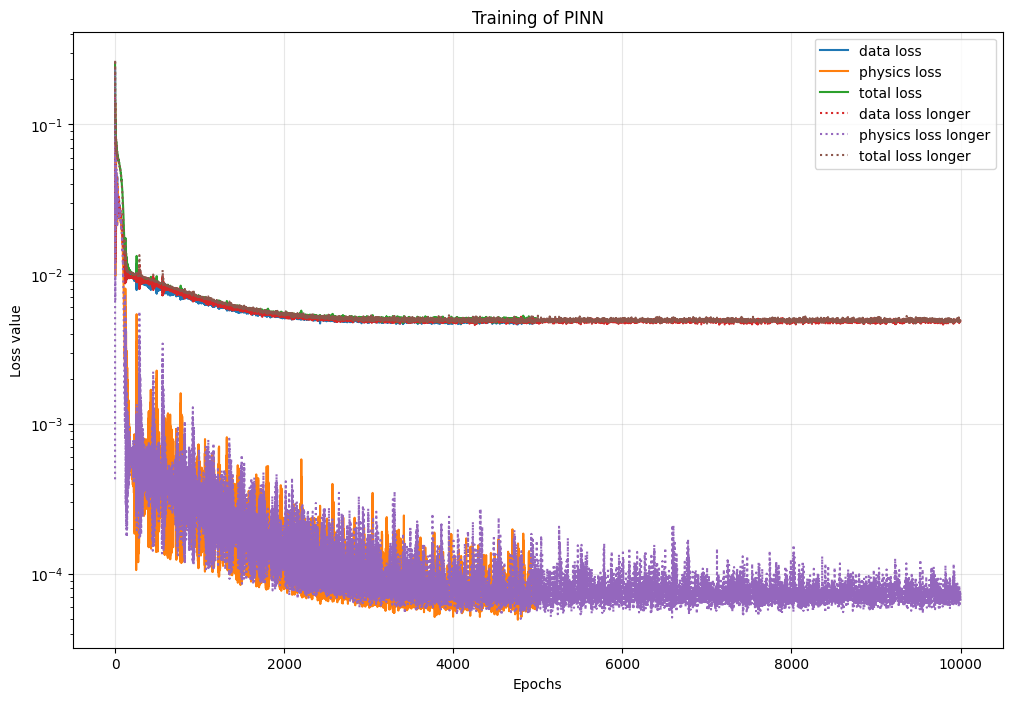

In [15]:
plt.figure(figsize=(12,8))
plt.semilogy(d_loss,label='data loss')
plt.semilogy(p_loss,label='physics loss')
plt.semilogy(t_loss,label='total loss')

plt.semilogy(d_loss_2,label='data loss longer',linestyle=":")
plt.semilogy(p_loss_2,label='physics loss longer',linestyle=":")
plt.semilogy(t_loss_2,label='total loss longer',linestyle=":")

plt.legend()
plt.grid(alpha=0.3)
plt.xlabel('Epochs')
plt.ylabel('Loss value')
plt.title('Training of PINN')


Text(0.5, 1.0, 'Diffusivity estimation acccross training')

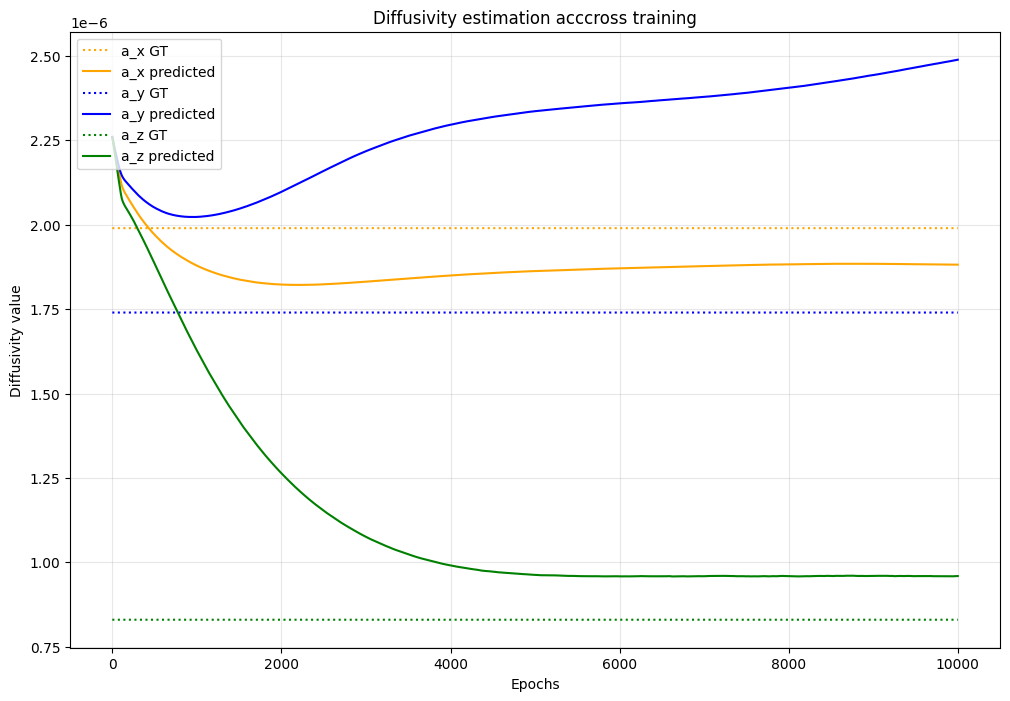

In [28]:
a_x_correct=torch.ones(10000)*1e-6*1.99
a_y_correct=torch.ones(10000)*1e-6*1.74
a_z_correct=torch.ones(10000)*1e-7*8.30
plt.figure(figsize=(12,8))

plt.plot(a_x_correct,label='a_x GT',linestyle=":",color='orange')
plt.plot(a_x_track,label='a_x predicted',color='orange')

plt.plot(a_y_correct,label='a_y GT',linestyle=":",color='blue')
plt.plot(a_y_track,label='a_y predicted',color='blue')

plt.plot(a_z_correct,label='a_z GT',linestyle=":",color='green')
plt.plot(a_z_track,label='a_z predicted',color='green')

plt.legend()
plt.grid(alpha=0.3)
plt.xlabel('Epochs')
plt.ylabel('Diffusivity value')
plt.title('Diffusivity estimation acccross training')

In [29]:
from helper_functions import SurfacePINN

In [30]:
model=SurfacePINN().to(device='cuda')
dict_path=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch/model_pinn_1_longer.pth")
model.load_state_dict(dict_path)
model.eval()
print(f"a_x: {model.alpha_x()} | a_y: {model.alpha_y()} | a_z: {model.alpha_z()} |")


a_x: tensor([1.8818e-06], device='cuda:0', grad_fn=<ExpBackward0>) | a_y: tensor([2.4890e-06], device='cuda:0', grad_fn=<ExpBackward0>) | a_z: tensor([9.5936e-07], device='cuda:0', grad_fn=<ExpBackward0>) |
